<div style="border:solid green 2px; padding: 20px">
    
<b>Арсений, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Это Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Модель оценки стоимости автомобилей
---

## Описание 

###  Общая информация

- заказчик: **AutoValue AI** - стартап, который внедряет модель мгновенного выкупа автомобилей на рынке подержанных автомобилей
- Как должнн работать сервис:
    - Клиент заполняет анкету в приложении.
    - Алгоритм за одну секунду рассчитывает стоимость.
    - Если клиента устраивает цена, он приезжает в ближайший офис продаж, где техник за 15 минут подтверждает состояние авто, а клиент мгновенно получает деньги на счёт.
- доступные данные -- информация о 10 000 прошлых сделок, которые эксперты провели вручную

## Бизнес-задача
Разработать автоматизированную систему оценки стоимости автомобилей, основанную на накопленном специалистами опыте. 
Внедрение модели позволит: 
- увеличить скорость оценки -- это позволит удержать больше клиентов
- повысить качество оценки -- это снизит риск убытков
- повысит пропускную способность сервиса (обслуживание большего количества клиентов в единицу времени) -- это способствует масштабированию бизнеса  

## Цель
- разработать модель машинного обучения для оценки автомобилей, учитывающую нелинейные связи между признаками

## Задачи
- определить наиболее эффективную библиотеку градиентного бустинга: LightGBM, CatBoost, XGBoost 
- минимизировать финансовые риски
- обеспечить прозрачность работы модели

## ML задача

Вид задачи:
- обучение с учителем
- подтип: регрессия 

Целевая переменная:
- **price_rub** -- рыночная стоимость автомобиля в рублях (для бизнеса это реальная сумма сделки, которую нужно предсказать).

Особенности:
- нелинейные свзяи между признаками
- отдельные датасеты под train и test

## Бизнес метрики
1. **Доля опасных переплат (Overpricing Rate)** - это процент случаев, когда модель предсказала цену на 20% выше реальной. Каждая такая машина — это прямой убыток. Покупая машину слишком дорого, компания не сможет перепродать с прибылью.

    Логика расчёта:

    - $Error Ratio = \frac{Предсказание−Реальность}{Реальность}$ 
    - если зачение > 0.2 - помечаем этот случай как «опасный».
    - Делим количество таких «опасных» случаев на общее количество машин в выборке

2. **Упущенная выгода (Underpricing Loss)** -  суммарная разница в случаях, когда модель занизила цену более чем на 20%. В таких случаях клиент просто развернётся и уйдёт к конкурентам. Компания теряет долю рынка.

    Логика расчета:
    - Находим все случаи, где наше предложение было ниже реальности более чем на 20% ($Error Ratio < -0.20$)
    - Для этих случаев вычисляем разницу между реальной ценой и нашим прогнозом. Это и есть сумма, которую недоплатили.
    - Суммируем все эти разницы




<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Корректно определена задача регрессии с учителем

---
## 1. Настройка проекта и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import optuna
import shap

In [2]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [3]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

In [4]:
# пути для скачивания данных
data_path_train = 'https://code.s3.yandex.net/datasets/ds_s16_train_data.csv'
data_path_test = 'https://code.s3.yandex.net/datasets/ds_s16_test_data.csv'

In [5]:
df_train = pd.read_csv(data_path_train)
display(df_train.info(), df_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


In [6]:
df_test = pd.read_csv(data_path_test)
display(df_test.info(), df_test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


Итог:
- данные для train и test считаны корректно
- явных пропусков нет
- типы данных соответсвуют описанию

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
    
* Все необходимые библиотеки импортированы в начале проекта
* Данные train и test загружены отдельно

---
## 2. EDA (Экспресс-анализ данных)
Бизнесу важно понимать природу данных.
- Изучите распределение целевой переменной price_rub.
- Проверьте корреляции.

### Общая информация

In [7]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [8]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [9]:
get_base_df_info(name='Train dataset', df=df_train)

Общая информация о датафрейме Train dataset


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


,Метрика,Значение
0,Строк,8000.0
1,Колонок,13.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,7.0
4,Числовых колонок,6.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
price_rub,int64,0,0.0,7929
mileage_kmpl,float64,0,0.0,2108
make_year,int64,0,0.0,29
engine_cc,int64,0,0.0,10
brand,object,0,0.0,10
color,object,0,0.0,6
accidents_reported,int64,0,0.0,6
region,object,0,0.0,6
owner_count,int64,0,0.0,5
fuel_type,object,0,0.0,3


Типы колонок


,Категориальные колонки,Числовые колонки
0,fuel_type,make_year
1,brand,mileage_kmpl
2,transmission,engine_cc
3,color,owner_count
4,service_history,accidents_reported
5,insurance_valid,price_rub
6,region,NaN


--------------------------------------------------


Анализ:
- явных дублей и пропусков нет
- 7 категориальных и 5 числовых признаков + таргет числовой

### Анализ распределений 

In [10]:
cat_cols, num_cols = get_cat_num_cols(df=df_train)

In [11]:
target_col = 'price_rub'
cat_cols_feat = cat_cols.copy()
num_cols_feat = [col for col in num_cols if col != target_col]

In [12]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins)
    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

#### Таргет

In [13]:
df_train[target_col].describe()

count    8.000000e+03
mean     6.836479e+05
std      2.649235e+05
min      9.500000e+04
25%      4.938570e+05
50%      6.638660e+05
75%      8.550560e+05
max      1.676525e+06
Name: price_rub, dtype: float64

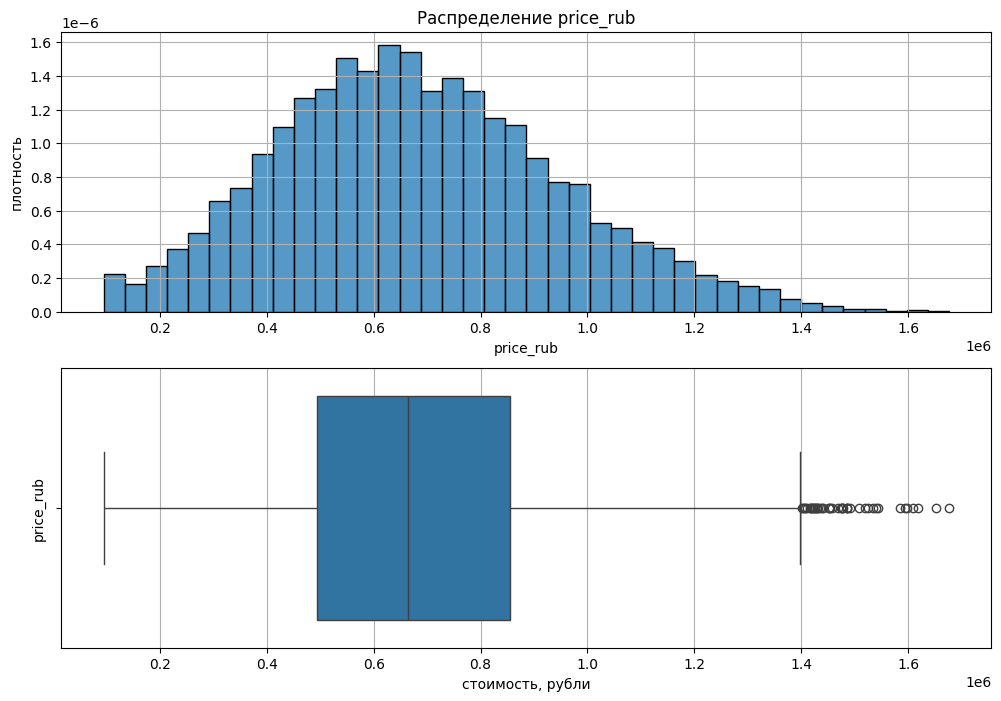

In [14]:
plot_hist_box(df=df_train, feature_name=target_col, x_label='стоимость, рубли', bins=40)

In [15]:
df_train[target_col].min()

np.int64(95000)

Анализ:
- распределение таргета симметричное (можно приблизить усеченным слева нормальным распределением)
- в правом хвосте распределения есть малочисленные выбросы 
- на левой границе можно отметить пороговое значение 95000 (подозрительно ровная сумма!), ниже которого значений нет. Возможно, это фиксированная нижняя цена для всех покупаемых на перепродажу авто. 

#### Количественные признаки

In [16]:
df_train[num_cols_feat].describe()

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2009.221250,17.946343,2289.687500,3.001125,0.487875
std,8.388703,5.015565,1289.812139,1.419199,0.693839
min,1995.000000,5.000000,800.000000,1.000000,0.000000
25%,2002.000000,14.530000,1200.000000,2.000000,0.000000
50%,2009.000000,17.970000,2000.000000,3.000000,0.000000
75%,2017.000000,21.350000,3000.000000,4.000000,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,5.000000


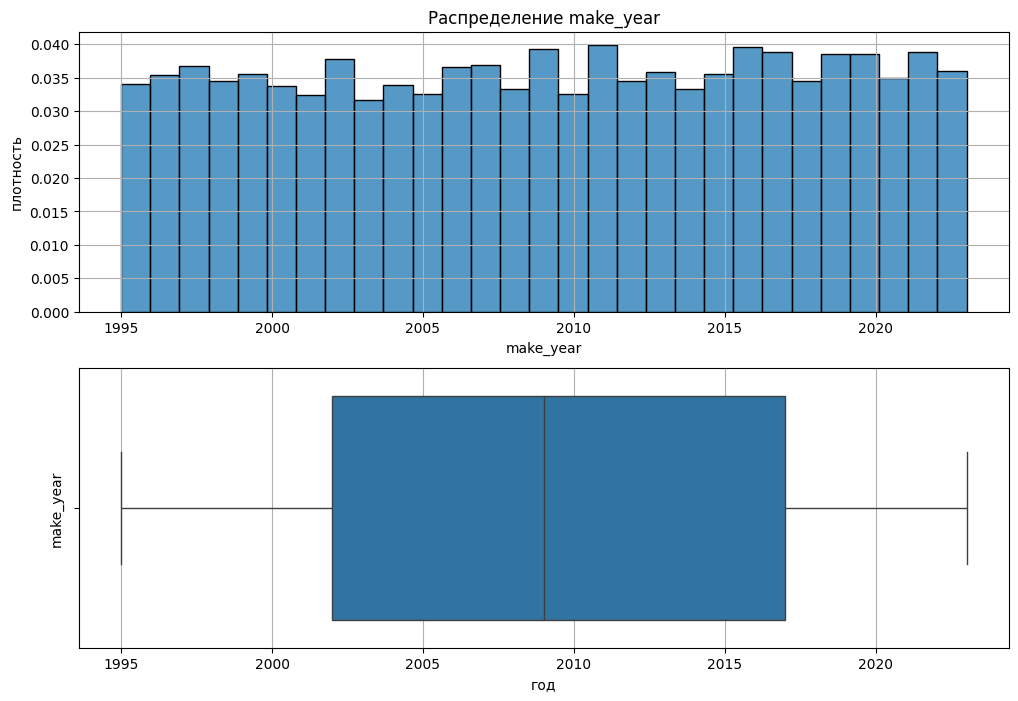

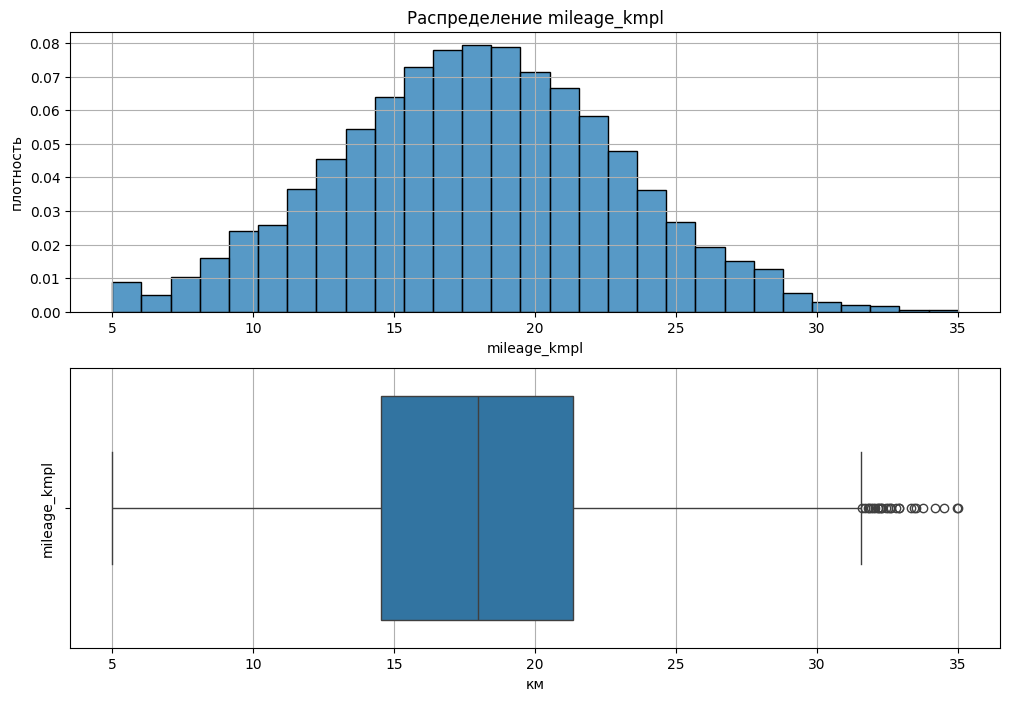

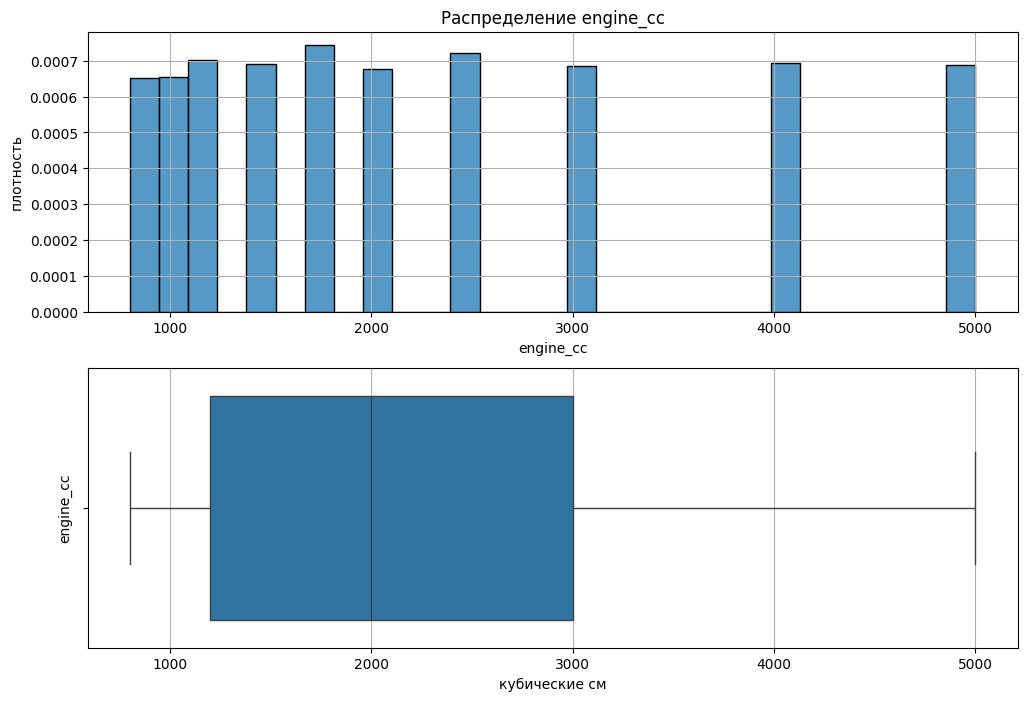

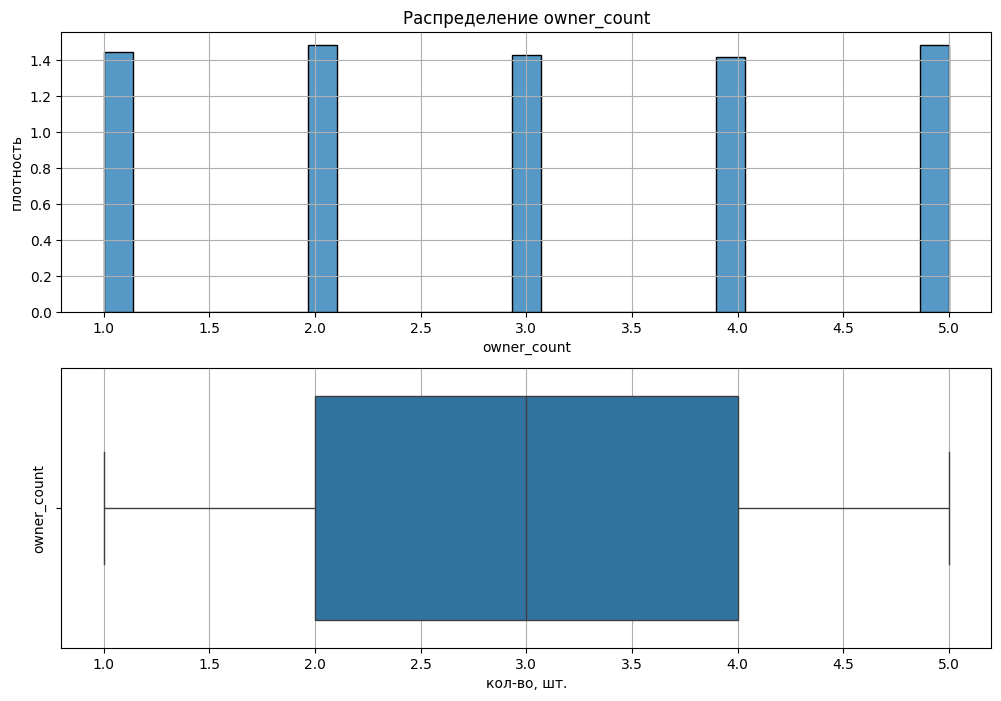

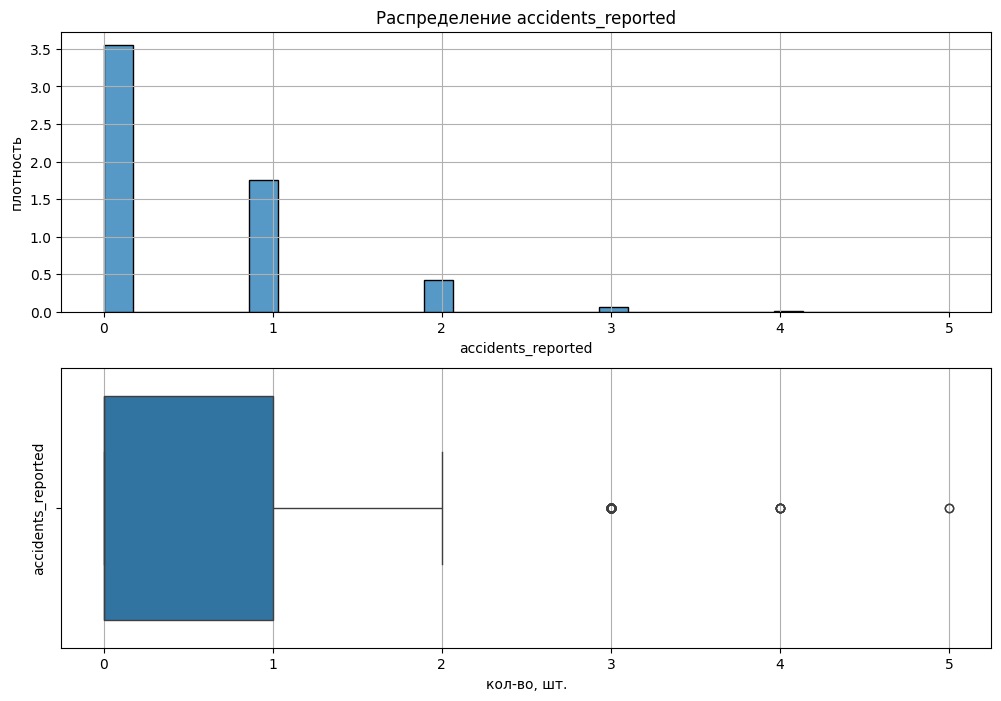

In [17]:
x_names = ['год', 'км', 'кубические см', 'кол-во, шт.', 'кол-во, шт.']
for col_name, x_name in zip(num_cols_feat, x_names):
    plot_hist_box(df=df_train, feature_name=col_name, x_label=x_name, bins=29)

Анализ:
- make_year	(Год выпуска) - распределение равномерное.
- mileage_kmpl	(кол-во литров на 1км) - симметричное распределение с явной минимальной границей в 5.0км. Есть малочисленные экстремальные значения на правом хвосте
- engine_cc	(Объём двигателя (в кубических см)) - дискретный набор стандартных по объему двигателя значений. Среди дискретных значений распределение равномерное. Чаще встречаются двигателя объемом до 2000 куб. см.
- owner_count	(Количество владельцев по ПТС) - от 1 до 5 целые значения. Распределение равномерное
- accidents_reported	(Количество зафиксированных ДТП) - от 0 до 5 целые значения. Распределение экспоненциально убывает. Чтобы усилить связь большого кол-ва ДТП с целевую переменной, стоит рассмотреть преобразование возведения в степень.

#### Категориальные данные 

In [18]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

    # горизонтальная линия среднего значения
    plt.axhline(
        y=mean_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Среднее: {mean_value:.1f}",
    )

    plt.title(f"Распределение признака {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)
    plt.legend()

    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [19]:
df_train[cat_cols_feat].describe()

,fuel_type,brand,transmission,color,service_history,insurance_valid,region
count,8000,8000,8000,8000,8000,8000,8000
unique,3,10,2,6,3,2,6
top,Petrol,Nissan,Manual,White,Full,Yes,Юг
freq,3990,870,4812,1366,3985,6356,1408


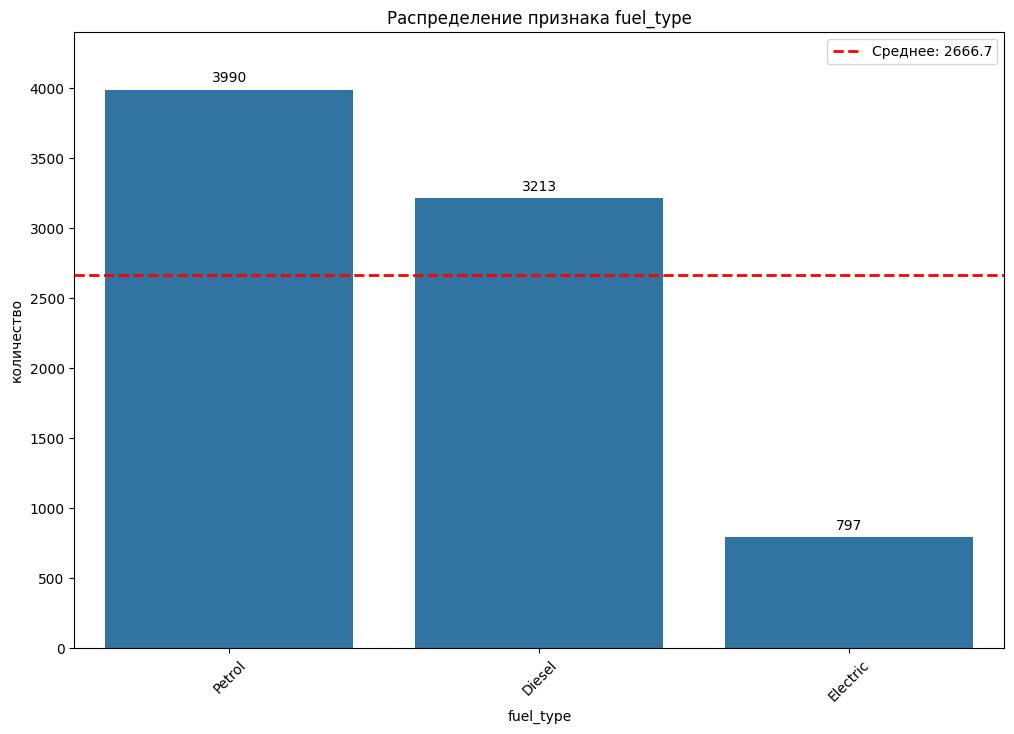

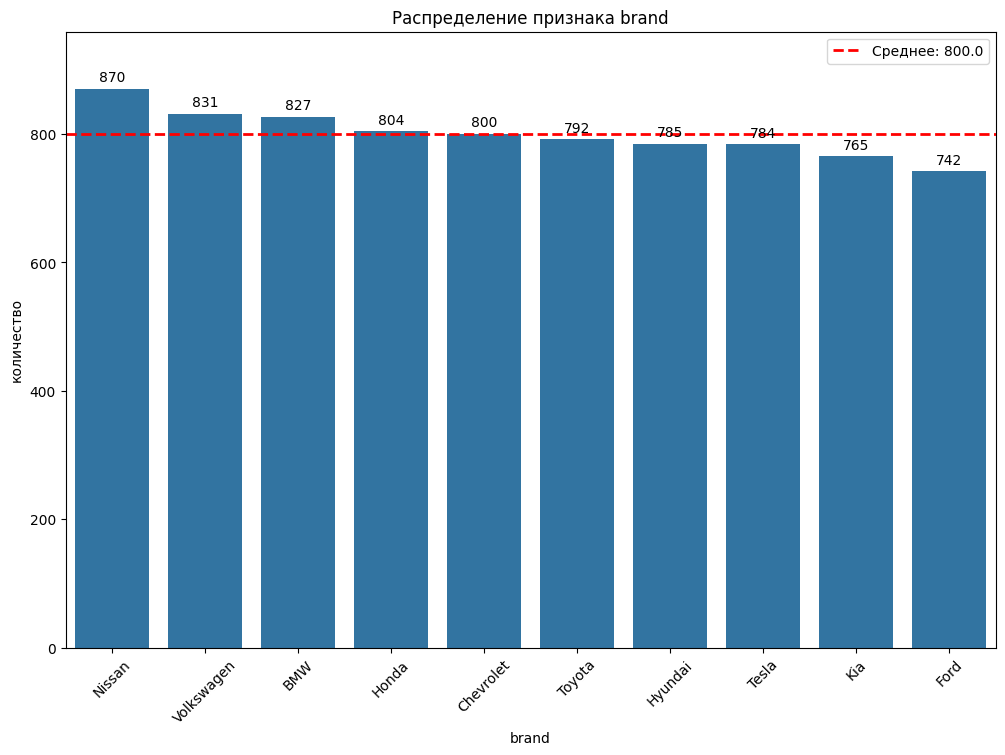

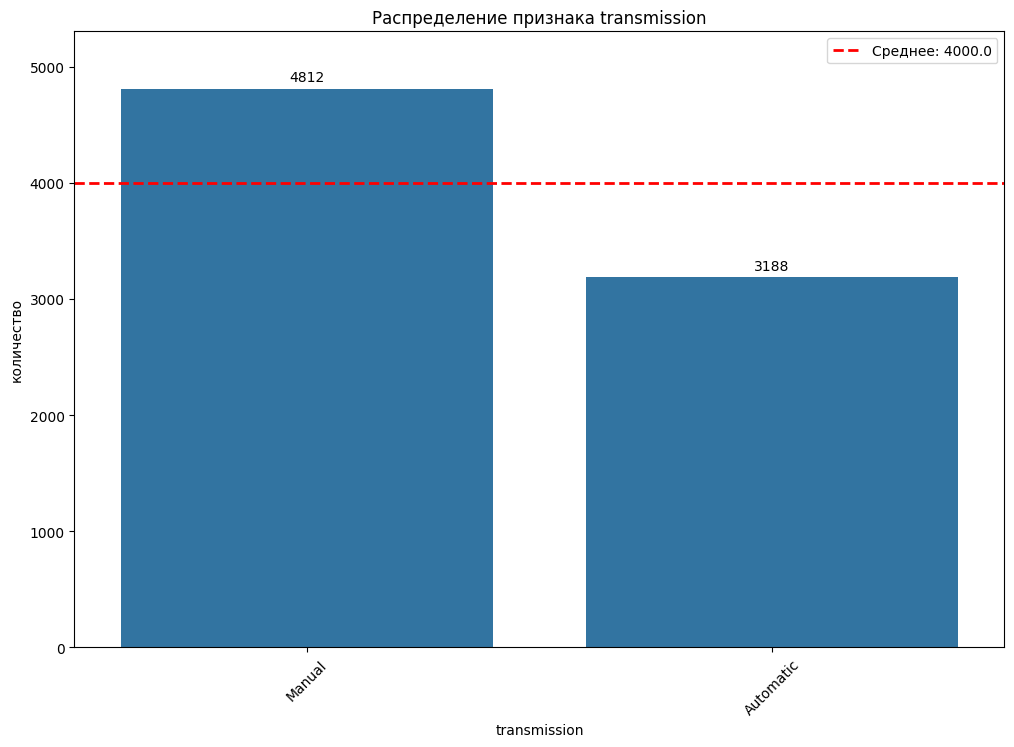

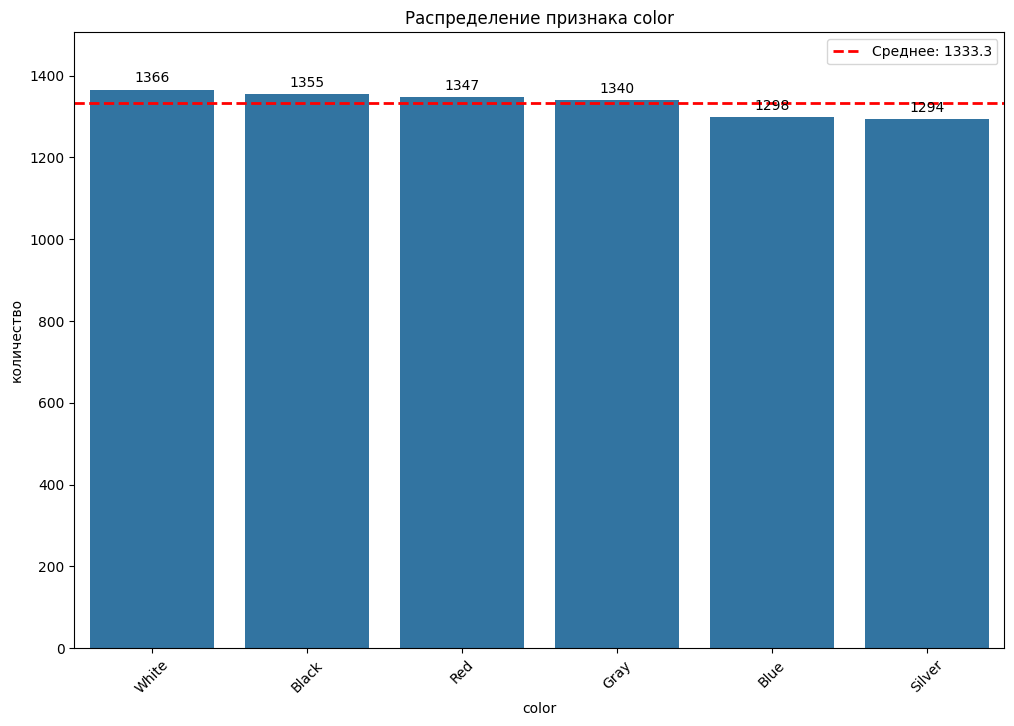

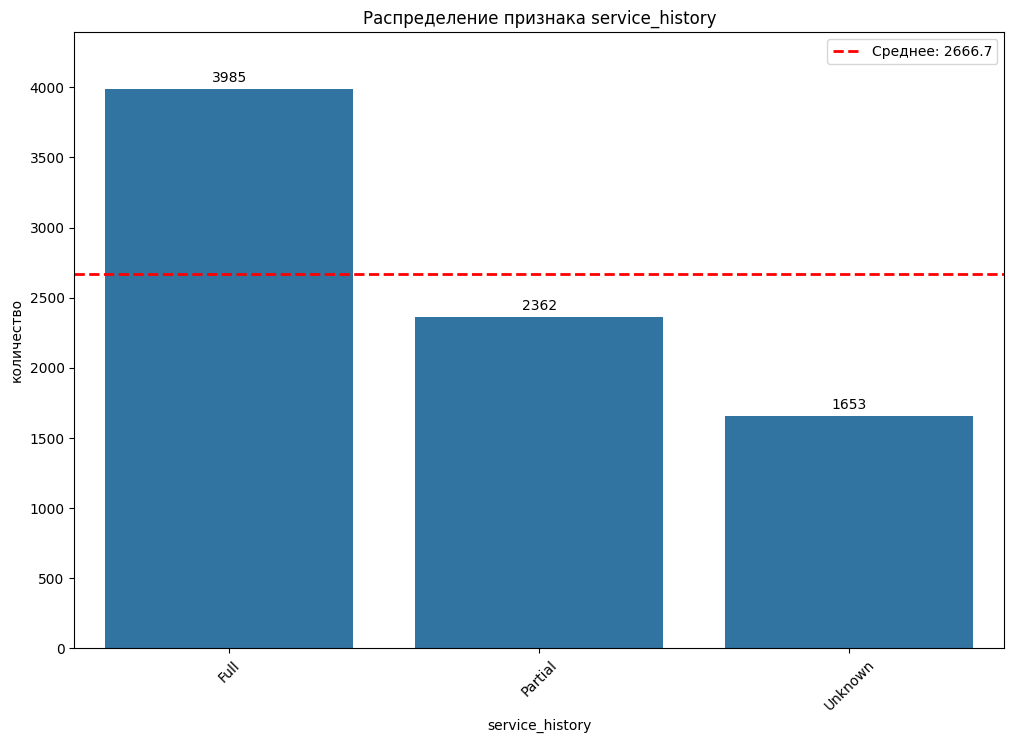

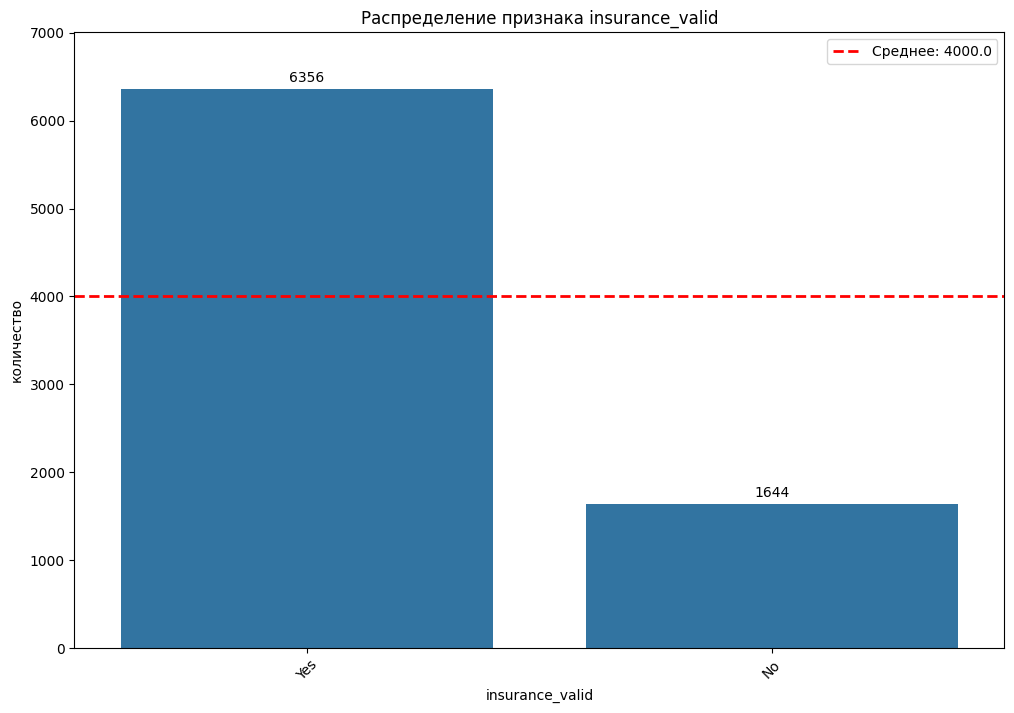

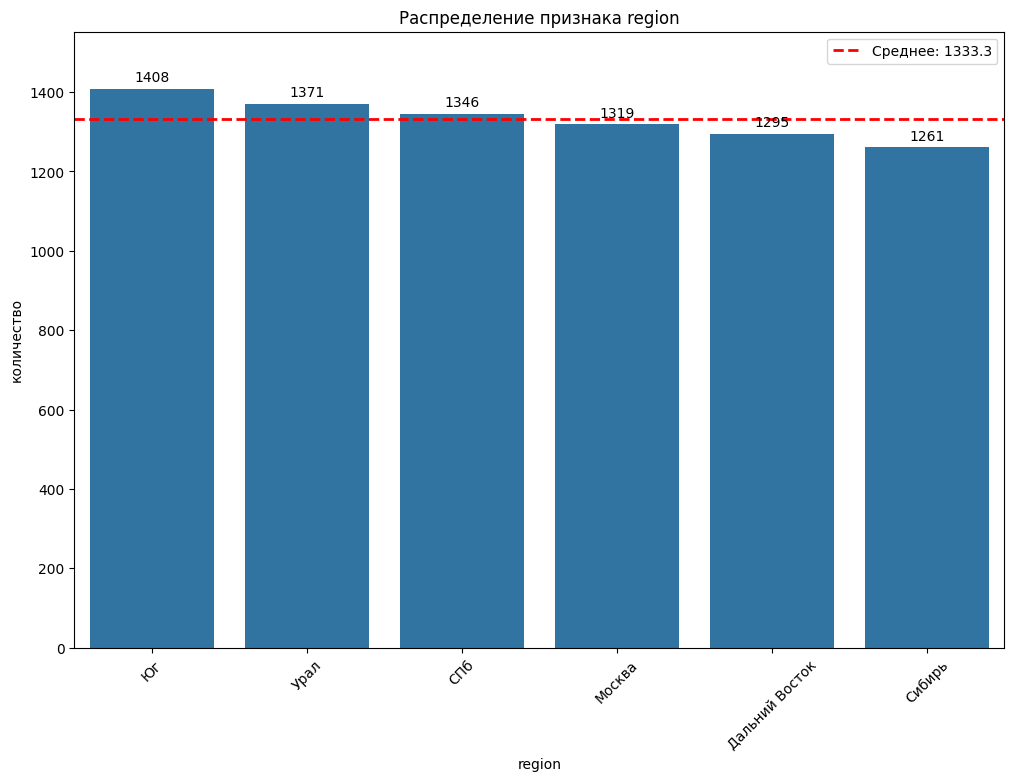

In [20]:
for name in cat_cols_feat:
    plot_count_bars(df=df_train, col_name=name)

Анализ:
- brand	(Марка автомобиля) - в лидерах Nissan, наименне пополярен Ford. По количеству все марки в пределах 10% около среднего.
- region (Макрорегион РФ, в котором продаётся автомобиль) - наиболее популярный ЮГ, наименее - Сибирь. Распределение в в пределах 10% около среднего. 
- color	(Цвет автомобиля) - распределение равномерное (черные и белые чаще встречаются, чем синие и серебрянные, но разница несущественная)
- insurance_valid	(Действительна ли страховка) - существенное преобладание авто с действующей на момент сделки страховки. Разница в 4 раза
- service_history	(Наличие сервисной книжки) - преобладают значения с полной историей, с частичной исторей меньше в ~1.5 раза, без истории меньше в ~2.5 раза
-  transmission	(Тип коробки передач) - механики в 1.5 раза больше, чем автомата
- fuel_type	(Тип топлива) - бензиновые двигателей на 20% больше, чем дизеля. Электрокары малочисленны - более чем в 4 раза меньше, чем остальных видов.

### Корреляционный анализ

In [21]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреляций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [22]:
corr_matrix = get_corr_matrix(
    data=df_train, 
    feat_cols=num_cols_feat + cat_cols_feat + [target_col], 
    num_cols=num_cols_feat + [target_col]
)

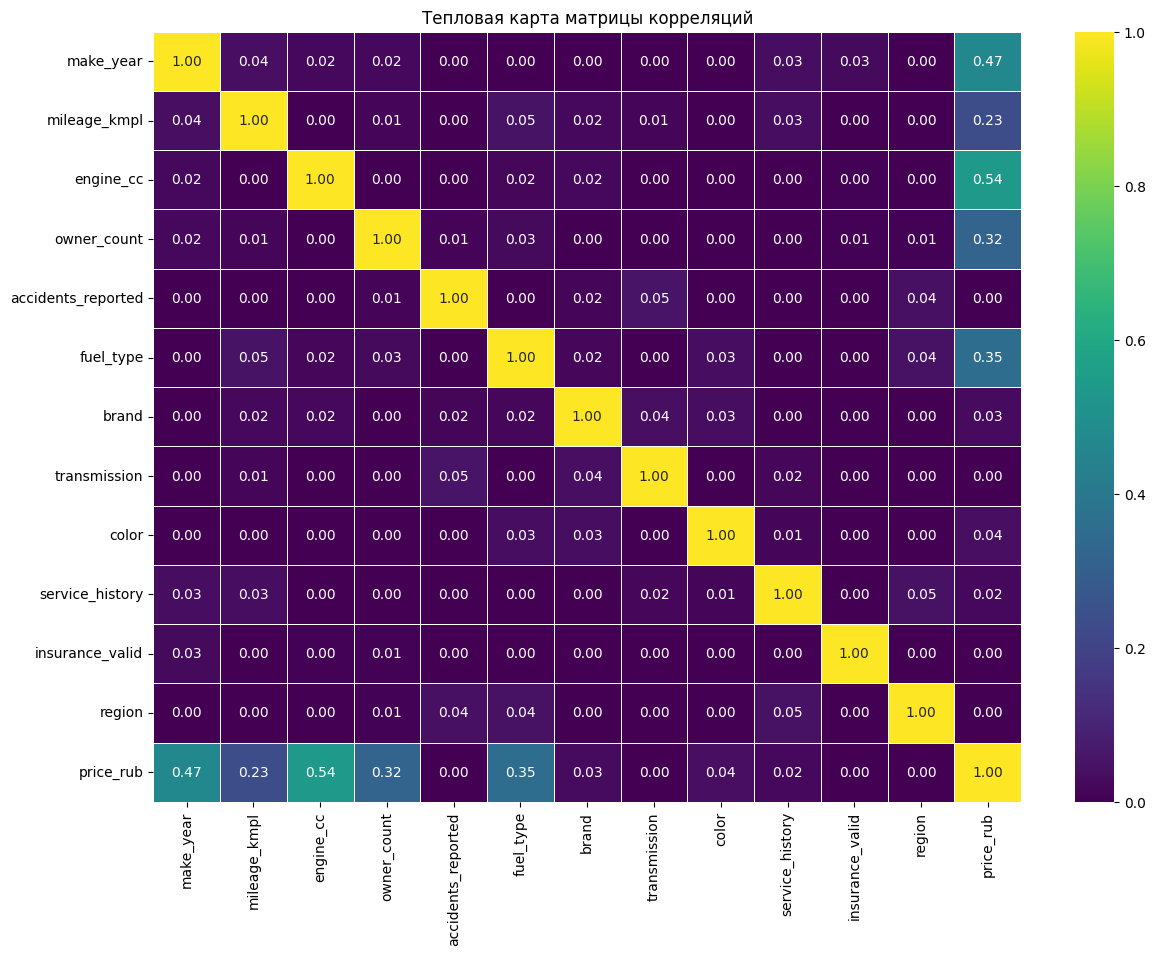

In [23]:
plot_corr_matrix(corr_matrix)

In [24]:
corr_with_target(corr_matrix=corr_matrix, target_col_name=target_col)

price_rub             1.000000
engine_cc             0.539546
make_year             0.466239
fuel_type             0.354523
owner_count           0.316419
mileage_kmpl          0.233398
color                 0.035179
brand                 0.028212
service_history       0.022291
accidents_reported    0.000000
transmission          0.000000
insurance_valid       0.000000
region                0.000000
Name: price_rub, dtype: float64

Анализ:
- наиболее сильная связь таргета с:
    - engine_cc (Объём двигателя) - предположительно, чем больше объем, тем дороже авто
    - make_year (Год выпуска) - предположительно, чем старше машина, тем она дешевле 
    - fuel_type (Тип топлива) - экономичность влияет на стоимость 
    - owner_count (Кол-во владельцев) - предположительно, чем больше было владельцев, тем больше просадка по цене

- По корреляции практически нет связи с:
    - accidents_reported - кол-во ДТП. Это довольно странно, на первый взгляд. Ведь кол-во ДТП должно существенно снижать ценник
    - transmission - коробка передач влияет на комфорт, но, видимо, не на цену
    - insurance_valid - наличие действующей страховки, предположительно, не такой важный фактор при формировании цены
    - region - от региона цена мало зависит 

Замечание:
- как упоминалось в ТЗ, связи могут быть нелинейными и корреляционный анализ может не отражать сложные, скрытые зависимости в данных

### Итог по ИАД

#### Общая информация:
- тренировочный датасет состоит из 8000 объектов
- 7 категориальных и 5 числовых признаков + таргет числовой
- пропусков и дублей нет

#### Распределения:

Таргет:
- распределение таргета симметричное (можно приблизить усеченным слева нормальным распределением)
- в правом хвосте распределения есть малочисленные выбросы 
- на левой границе можно отметить пороговое значение 95000 (подозрительно ровная сумма!), ниже которого значений нет. Возможно, это фиксированная нижняя цена для всех покупаемых на перепродажу авто. 

Количественные признаки:
- make_year	(Год выпуска) - распределение равномерное.
- mileage_kmpl	(Пробег (км)) - симметричное распределение с явной минимальной границей в 5.0км. Есть малочисленные экстремальные значения на правом хвосте
- engine_cc	(Объём двигателя (в кубических см)) - дискретный набор стандартных по объему двигателя значений. Среди дискретных значений распределение равномерное. Чаще встречаются двигателя объемом до 2000 куб. см.
- owner_count	(Количество владельцев по ПТС) - от 1 до 5 целые значения. Распределение равномерное
- accidents_reported	(Количество зафиксированных ДТП) - от 0 до 5 целые значения. Распределение экспоненциально убывает. Чтобы усилить связь большого кол-ва ДТП с целевую переменной, стоит рассмотреть преобразование возведения в степень.


Категориальные:
- brand	(Марка автомобиля) - в лидерах Nissan, наименне пополярен Ford. По количеству все марки в пределах 10% около среднего.
- region (Макрорегион РФ, в котором продаётся автомобиль) - наиболее популярный ЮГ, наименее - Сибирь. Распределение в в пределах 10% около среднего. 
- color	(Цвет автомобиля) - распределение равномерное (черные и белые чаще встречаются, чем синие и серебрянные, но разница несущественная)
- insurance_valid	(Действительна ли страховка) - существенное преобладание авто с действующей на момент сделки страховки. Разница в 4 раза
- service_history	(Наличие сервисной книжки) - преобладают значения с полной историей, с частичной исторей меньше в ~1.5 раза, без истории меньше в ~2.5 раза
-  transmission	(Тип коробки передач) - механики в 1.5 раза больше, чем автомата
- fuel_type	(Тип топлива) - бензиновые двигателей на 20% больше, чем дизеля. Электрокары малочисленны - более чем в 4 раза меньше, чем остальных видов.

#### Корреляционный анализ:

- наиболее сильная связь таргета с:
    - engine_cc (Объём двигателя) - предположительно, чем больше объем, тем дороже авто
    - make_year (Год выпуска) - предположительно, чем старше машина, тем она дешевле 
    - fuel_type (Тип топлива) - экономичность влияет на стоимость 
    - owner_count (Кол-во владельцев) - предположительно, чем больше было владельцев, тем больше просадка по цене

- По корреляции практически нет связи с:
    - accidents_reported - кол-во ДТП. Это довольно странно, на первый взгляд. Ведь кол-во ДТП должно существенно снижать ценник
    - transmission - коробка передач влияет на комфорт, но, предположительно, не на цену
    - insurance_valid - наличие действующей страховки, предположительно, не такой важный фактор при формировании цены
    - region - от региона цена, предположительно, мало зависит 

Замечание:
- связи могут быть нелинейными и корреляционный анализ может не отражать сложные, скрытые зависимости в данных


#### Выводы
- для количественных данных с симметричными распределениями можно рассмотреть фильтрацию экстремальных внутри пайплайна предобработки данных
- для дискретных данных, которые показали низкую корреляцию с таргетом можно попробовать применить преобразование признаков: возведение в степень для accidents_reported, например 

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
    
* Проверены пропуски, дубликаты, типы и число уникальных значений
* Для корреляционного анализа использован Phik, подходящий для смешанных типов данных

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
    "mileage_kmpl (Пробег (км))"

Это не накопленный пробег автомобиля. kmpl означает kilometers per liter - количество километров на одном литре топлива, т.е. топливную экономичность

<div class="alert alert-info"> <b>Комментарии студента:</b> Спасибо за комментарий! Исправил. Я брал это из описания проекта на платформе практикума, там неверная информация указана.</div>

---
## 3. Предобработка

- Подготовьте признаки.
- Сформируйте одинаковые обучающие и валидационные выборки для всех трёх библиотек.
- Используйте файл ds_s16_test_data.csv как отложенную тестовую выборку.

In [25]:
for col in cat_cols_feat:
	# приведение всех категориальных признаков к pd.categorical
	df_train[col] = df_train[col].astype('category')


#### Разделение на выборки

In [26]:
X_train_val = df_train.drop(columns='price_rub')
y_train_val = pd.Series(df_train['price_rub'], name='target')
display(X_train_val.head(), y_train_val)

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,Сибирь


0       242073
1       426029
2       727050
3       753168
4       733390
         ...  
7995    993550
7996    487962
7997    808630
7998    642222
7999    622646
Name: target, Length: 8000, dtype: int64

In [27]:
# train 80% и validate 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [28]:
X_train.shape, X_val.shape

((6400, 12), (1600, 12))

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Train и validation разделены в пропорции 50/50. В результате для обучения остается только 4000 объектов, хотя доступно 8000.

Более рационально использовать, например, 80/20: это даст моделям больше данных для обучения и при этом оставит достаточно объектов для надежной валидации

<div class="alert alert-info"> <b>Комментарии студента:</b> Согласен, сделал более рациональное разделение.</div>

---
## 4. Обучение моделей в разных библиотеках

Проведите первый раунд «турнира библиотек» на базовых настройках.

Обучите три модели: XGBoost, CatBoost и LightGBM.

Сравните их базовые метрики (RMSE, MAE, R²).

Основаная метрика в турнире: MAE (Mean Absolute Error)

Сравните их также по бизнес-метрикам:
- Overpricing Rate — доля случаев, когда модель завысила цену более чем на 20%.
- Underpricing Loss — суммарная потеря, когда цена была занижена более чем на 20%.

In [29]:
def get_overpricing_rate(y_true, y_pred):
    # Рассчитываем относительное отклонение
    error_ratio = (y_pred - y_true) / y_true
    # Считаем долю тех, где отклонение выше 20%
    overpricing_rate = (error_ratio > 0.20).mean()

    return overpricing_rate


def get_underpricing_loss(y_true, y_pred):
    error_ratio = (y_pred - y_true) / y_true
    # Находим маску (фильтр) для случаев занижения цены на 20%+
    under_mask = error_ratio < -0.20
    # Суммируем разницу между реальной ценой и предсказанием для этих случаев
    underpricing_loss = (y_true[under_mask] - y_pred[under_mask]).sum()
    return underpricing_loss

def calc_metrics(y_pred, y_true, model_name: str):
    # 1
    overpricing_rate = get_overpricing_rate(y_true, y_pred)

    # 2
    underpricing_loss = get_underpricing_loss(y_true, y_pred)

    # 3
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    result_df = pd.DataFrame(
        {   'model_name': model_name,
            'overpricing_rate': overpricing_rate,
            'underpricing_loss': underpricing_loss,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }, index=[0]
    )
    return result_df

### Обучение базовой модели XGBoost

In [30]:
def plot_xgb_model_learning_curve(xgb_model):
    # Достаём значения метрики rmse на каждой итерации обучения
    results = xgb_model.evals_result()

    epochs = len(results['validation_0']['mae'])
    x = range(epochs)

    # Строим график
    plt.plot(x, results['validation_0']['mae'], label='MAE на обучающей выборке')
    plt.plot(x, results['validation_1']['mae'], label='MAE на валидационной выборке')
    plt.xlabel('Кол-во итераций (n_estimators)')
    plt.ylabel('Значение MAE')
    plt.title('График зависимости значения MAE на обучающей/валидационной выборках')
    plt.legend()
    plt.grid(True)
    plt.show()

In [31]:
xgb_model_base = XGBRegressor(
    objective='reg:absoluteerror',  # минимизация MAE на train
    random_state=RANDOM_SEED, 
    enable_categorical=True,
    learning_rate=0.3,
    eval_metric="mae", # оценка MAE на validate
    n_estimators=100,
    n_jobs=-1,
    early_stopping_rounds=20
)

In [32]:
# Обучаем модель с eval_set
xgb_model_base.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=20,
             enable_categorical=True, eval_metric='mae', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.3, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, objective='reg:absoluteerror', ...)

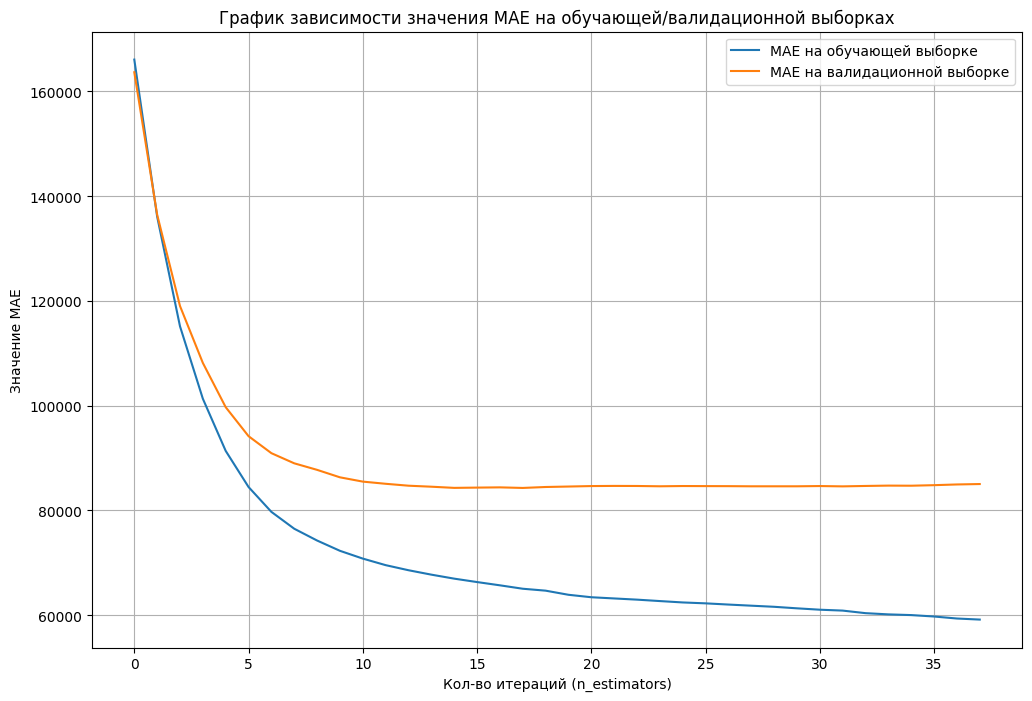

In [33]:
plot_xgb_model_learning_curve(xgb_model_base)

Анализ:
- без ранней остановки бустинг существенно переобучается: на validate ошибка перестает падать после 10ой итерации

In [34]:
# метрики на validate
y_val_pred_xgb_model_base = xgb_model_base.predict(X_val)
xgb_model_base_metrics = calc_metrics(
    y_pred=y_val_pred_xgb_model_base, y_true=y_val, model_name='xgb_model_base'
)
xgb_model_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,xgb_model_base,0.146875,2.228710e+07,106645.9375,84286.460938,0.832067


### Обучение базовой модели LightGBM

In [35]:
lgbm_base = LGBMRegressor(
    objective='regression_l1', # MAE функция потерь
    metric='mae', # оценка по MAE на валиадции 
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

In [36]:
lgbm_base.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols_feat, 
    eval_metric='mae',
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 347
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 12
[LightGBM] [Info] Start training from score 662700.500000


LGBMRegressor(metric='mae', n_jobs=-1, objective='regression_l1',
              random_state=42)

In [37]:
# предсказания на validate
y_pred_val_lgbm_base = lgbm_base.predict(X_val)

In [38]:
lgbm_base_metrics = calc_metrics(
    y_pred=y_pred_val_lgbm_base, y_true=y_val, model_name='lgbm_base'
)
lgbm_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,lgbm_base,0.139375,1.955611e+07,102803.932005,81979.305408,0.843949


### Обучение базовой модели CatBoost

In [39]:
# Инициализируем CatBoostRegressor
cbr_model_base = CatBoostRegressor(
    loss_function='MAE',
    eval_metric='MAE',
    random_state=RANDOM_SEED, 
    iterations=3000,               # максимум итераций
    l2_leaf_reg=1.0,               # регуляризация
    early_stopping_rounds=200,     # остановка при отсутствии улучшения
    use_best_model=True,           # сохранить лучшую модель
)

In [40]:
cbr_model_base.fit(
    X_train,
    y_train,
    cat_features=cat_cols_feat,
    eval_set=(X_val, y_val),
    verbose=200,
    use_best_model=True
)

0:	learn: 208483.8811081	test: 202214.2293712	best: 202214.2293712 (0)	total: 58.3ms	remaining: 2m 54s
200:	learn: 73667.6616613	test: 79815.2632950	best: 79815.2632950 (200)	total: 474ms	remaining: 6.6s
400:	learn: 71181.0602919	test: 79412.0710348	best: 79401.2998240 (373)	total: 879ms	remaining: 5.7s
600:	learn: 69470.9365214	test: 79296.5452914	best: 79296.1562397 (599)	total: 1.27s	remaining: 5.08s
800:	learn: 68283.3796805	test: 79333.5141863	best: 79293.9605724 (605)	total: 1.64s	remaining: 4.5s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 79293.96057
bestIteration = 605

Shrink model to first 606 iterations.


CatBoostRegressor(early_stopping_rounds=200, eval_metric='MAE', iterations=3000, l2_leaf_reg=1.0, loss_function='MAE', random_state=42, use_best_model=True)

In [41]:
# предсказания на validate
y_pred_val_cbr_model_base = cbr_model_base.predict(X_val)

In [42]:
cbr_base_metrics = calc_metrics(
    y_pred=y_pred_val_cbr_model_base, y_true=y_val, model_name='cbr_model_base'
)
cbr_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,cbr_model_base,0.13375,1.650619e+07,98955.455291,79293.960573,0.855414


### Сравнительная таблица

In [43]:
results = pd.concat(
    [cbr_base_metrics, lgbm_base_metrics, xgb_model_base_metrics],
).sort_values(by='mae')
results

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,cbr_model_base,0.133750,1.650619e+07,98955.455291,79293.960573,0.855414
0,lgbm_base,0.139375,1.955611e+07,102803.932005,81979.305408,0.843949
0,xgb_model_base,0.146875,2.228710e+07,106645.937500,84286.460938,0.832067


Анализ:
- по всем метрикам CatBoostRegressor лидирует:
    - по overpricing_rate: у LGBMRegressor на 1% больше , у XGBRegressor на 10%
    - underpricing_loss: у LGBMRegressor  больше на ~20%, у XGBRegressor больше на ~50%
    - rmse,	mae: у CatBoostRegressor меньше на 5-7%
    - r2: у CatBoostRegressor больше на 2-3%

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Перепутан порядок y_true и y_pred Функция объявлена корректно:

    def calc_metrics(y_true, y_pred, model_name):

Но вызывается наоборот:

    calc_metrics(y_val_pred_xgb_model_base, y_val, ...)
    calc_metrics(y_pred_val_lgbm_base, y_val, ...)
    calc_metrics(y_pred_val_cbr_model_base, y_val, ...)

Первым аргументом передаются прогнозы, а вторым - реальные значения. У тебя


* Overpricing Rate и Underpricing Loss считаются в обратном направлении
* R2 рассчитывается некорректно, потому что эта метрика несимметрична
* вывод о финансовых рисках моделей поулчается, что недостоверен

Нужно везде вызывать функцию так:

    calc_metrics(y_val, y_pred, model_name)

После этого пересчитать все таблицы и выводы
    
    
---    

Сейчас MAE не используется как целевая функция моделей. В задании требуется обучать все модели с MAE как функцией потерь. У XGBoost указано только:

    eval_metric='mae'

но отсутствует:

    objective='reg:absoluteerror'

У LightGBM не задано:

    objective='mae'

CatBoost базово обучается с:

    loss_function='RMSE'

Таким образом, модели сравниваются при разных функциях потерь

Вот так правильнее:

    XGBRegressor(objective='reg:absoluteerror', ...)
    LGBMRegressor(objective='mae', ...)
    CatBoostRegressor(loss_function='MAE', ...)

После этого переобучить базовые модели и обновить сравнение.

<div class="alert alert-info"> <b>Комментарии студента:</b> Исправил. Метрики пересчитал. Вывод тоже поправил. </div>

---
## 5. Работа с параметрами модели (Тюнинг)


### Подбор гиперпараметров для XGBRegressor

In [44]:
def objective_xgb(trial):
    """
    Функция-цель для оптимизации параметров xgb
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0),
        "random_state": RANDOM_SEED, 
        "enable_categorical": True,
        "eval_metric": "mae", 
        "n_jobs": -1, 
        "early_stopping_rounds": 30
    }

    model = XGBRegressor(
        **params, 
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )
    y_val_pred = model.predict(X_val)

    score = mean_absolute_error(y_val, y_val_pred)

    return score

In [45]:
# исследование
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

In [ ]:
# запуск оптимизации
study_xgb = optuna.create_study(direction="minimize", sampler=sampler) 
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True) 

[I 2026-06-23 10:44:15,198] A new study created in memory with name: no-name-f0f0c62f-2827-42a3-8244-916669f229b9


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-23 10:44:16,167] Trial 0 finished with value: 89230.1015625 and parameters: {'learning_rate': 0.023688639503640783, 'max_depth': 10, 'n_estimators': 1598, 'gamma': 0.5986584882104518, 'reg_lambda': 1.5601864128641787, 'reg_alpha': 1.5599452118020811}. Best is trial 0 with value: 89230.1015625.
[I 2026-06-23 10:44:17,649] Trial 1 finished with value: 87887.3828125 and parameters: {'learning_rate': 0.011430983876313222, 'max_depth': 9, 'n_estimators': 1402, 'gamma': 0.7080725807153196, 'reg_lambda': 0.2058449527521795, 'reg_alpha': 9.699098521920844}. Best is trial 1 with value: 87887.3828125.
[I 2026-06-23 10:44:17,932] Trial 2 finished with value: 80468.15625 and parameters: {'learning_rate': 0.06798962421591129, 'max_depth': 4, 'n_estimators': 772, 'gamma': 0.1834045180193887, 'reg_lambda': 3.0424224365529544, 'reg_alpha': 5.2475643210748135}. Best is trial 2 with value: 80468.15625.
[I 2026-06-23 10:44:18,507] Trial 3 finished with value: 81502.640625 and parameters: {'lea

In [ ]:
xgb_best_opt = XGBRegressor(
    **study_xgb.best_params, 
    enable_categorical=True,
)

In [ ]:
xgb_best_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
y_val_pred_xgb_best_opt = xgb_best_opt.predict(X_val)
xgb_best_opt_metrics = calc_metrics(
    y_val_pred_xgb_best_opt, y_val, model_name='xgb_best_opt'
)
xgb_best_opt_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,xgb_best_opt,0.118,68643844.5,102802.28125,82303.359375,0.822828


### Подбор гиперпараметров для LGBMRegressor

In [ ]:
def objective_lgbm(trial):
    """
    Функция-цель для оптимизации параметров lgbm
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "num_leaves": trial.suggest_int("num_leaves", 20, 256),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "random_state": RANDOM_SEED, 
        "enable_categorical": True,
        "eval_metric": "mae", 
        "n_jobs": -1, 
        "early_stopping_rounds": 30,
        "verbose": -1,
    }

    model = LGBMRegressor(
        **params, 
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
    )
    y_val_pred = model.predict(X_val)

    score = mean_absolute_error(y_val, y_val_pred)

    return score

In [ ]:
# запуск оптимизации
study_lgbm = optuna.create_study(direction="minimize", sampler=sampler) 
study_lgbm.optimize(objective_lgbm, n_trials=30, show_progress_bar=True) 

[I 2026-06-22 00:48:51,317] A new study created in memory with name: no-name-096838a7-fad4-4f45-89cf-acd7dc96d779


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-22 00:48:52,541] Trial 0 finished with value: 80230.14049248684 and parameters: {'learning_rate': 0.02447244097399012, 'max_depth': 5, 'n_estimators': 1743, 'num_leaves': 104, 'min_child_samples': 31, 'reg_lambda': 0.0002195678075127562, 'reg_alpha': 1.3408920002835402e-07}. Best is trial 0 with value: 80230.14049248684.
[I 2026-06-22 00:48:52,913] Trial 1 finished with value: 79126.01339798536 and parameters: {'learning_rate': 0.06341572775495277, 'max_depth': 3, 'n_estimators': 1981, 'num_leaves': 203, 'min_child_samples': 24, 'reg_lambda': 1.1070747281639212e-08, 'reg_alpha': 0.03339576740674936}. Best is trial 1 with value: 79126.01339798536.
[I 2026-06-22 00:48:53,831] Trial 2 finished with value: 80988.88768998138 and parameters: {'learning_rate': 0.050916359458185526, 'max_depth': 8, 'n_estimators': 1657, 'num_leaves': 37, 'min_child_samples': 39, 'reg_lambda': 8.451863533931625e-08, 'reg_alpha': 0.08032068562667226}. Best is trial 1 with value: 79126.01339798536.
[I 

In [ ]:
lgbm_best_opt = LGBMRegressor(
    **study_lgbm.best_params, 
)

In [ ]:
lgbm_best_opt.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
)
y_val_pred_lgbm_best_opt = lgbm_best_opt.predict(X_val)
lgbm_best_opt_metrics = calc_metrics(
    y_val_pred_lgbm_best_opt, y_val, model_name='lgbm_best_opt'
)
lgbm_best_opt_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,lgbm_best_opt,0.10225,6.325386e+07,98766.12956,78946.494447,0.831815


### Подбор гиперпараметров для CatBoost

In [ ]:
def objective_catboost(trial):
    """
    Функция-цель для оптимизации параметров catboost
    """

    # Пространство поиска
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 10),
        "random_state": RANDOM_SEED, 
        "loss_function": "RMSE", 
        "eval_metric": "MAE",
        "early_stopping_rounds": 30,
        "use_best_model":True,   
        "verbose": False,
    }

    model = CatBoostRegressor(
        **params, 
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols_feat,
    )
    y_val_pred = model.predict(X_val)

    score = mean_absolute_error(y_val, y_val_pred)

    return score

In [ ]:
# запуск оптимизации
study_catboost = optuna.create_study(direction="minimize", sampler=sampler) 
study_catboost.optimize(objective_catboost, n_trials=30, show_progress_bar=True) 

[I 2026-06-22 00:49:31,716] A new study created in memory with name: no-name-8732aeb2-956b-4996-9bbb-e24b253ec1f7


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-06-22 00:49:32,395] Trial 0 finished with value: 77916.77087757448 and parameters: {'learning_rate': 0.02614634594933435, 'max_depth': 4, 'n_estimators': 679, 'l2_leaf_reg': 4}. Best is trial 0 with value: 77916.77087757448.
[I 2026-06-22 00:49:32,683] Trial 1 finished with value: 78441.60183169966 and parameters: {'learning_rate': 0.08768184989765529, 'max_depth': 5, 'n_estimators': 1278, 'l2_leaf_reg': 8}. Best is trial 0 with value: 77916.77087757448.
[I 2026-06-22 00:49:33,950] Trial 2 finished with value: 79253.5418677046 and parameters: {'learning_rate': 0.02310093735409802, 'max_depth': 10, 'n_estimators': 1944, 'l2_leaf_reg': 3}. Best is trial 0 with value: 77916.77087757448.
[I 2026-06-22 00:49:34,556] Trial 3 finished with value: 78171.21330885537 and parameters: {'learning_rate': 0.03142306225908967, 'max_depth': 5, 'n_estimators': 927, 'l2_leaf_reg': 1}. Best is trial 0 with value: 77916.77087757448.
[I 2026-06-22 00:49:35,253] Trial 4 finished with value: 78641.844

In [ ]:
catboost_best_opt = CatBoostRegressor(
    **study_catboost.best_params, 
)

In [ ]:
catboost_best_opt.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_cols_feat,
)
y_val_pred_catboost_best_opt = catboost_best_opt.predict(X_val)
catboost_best_opt_metrics = calc_metrics(
    y_val_pred_catboost_best_opt, y_val, model_name='catboost_best_opt'
)
catboost_best_opt_metrics

0:	learn: 264619.0224531	test: 262065.3863533	best: 262065.3863533 (0)	total: 1.54ms	remaining: 2.66s
1:	learn: 263009.9529502	test: 260460.6330903	best: 260460.6330903 (1)	total: 2.96ms	remaining: 2.55s
2:	learn: 261436.8435797	test: 258887.9286676	best: 258887.9286676 (2)	total: 3.56ms	remaining: 2.04s
3:	learn: 259918.0773666	test: 257340.8746096	best: 257340.8746096 (3)	total: 4.7ms	remaining: 2.02s
4:	learn: 258402.9576759	test: 255811.8410684	best: 255811.8410684 (4)	total: 5.26ms	remaining: 1.81s
5:	learn: 256872.0339109	test: 254281.1218698	best: 254281.1218698 (5)	total: 6.03ms	remaining: 1.73s
6:	learn: 255389.7071199	test: 252806.4234537	best: 252806.4234537 (6)	total: 6.76ms	remaining: 1.66s
7:	learn: 253896.7153620	test: 251314.8835191	best: 251314.8835191 (7)	total: 7.47ms	remaining: 1.6s
8:	learn: 252451.6643764	test: 249878.6702361	best: 249878.6702361 (8)	total: 8.71ms	remaining: 1.66s
9:	learn: 251000.8841438	test: 248426.2647158	best: 248426.2647158 (9)	total: 9.36ms

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,catboost_best_opt,0.102,6.078927e+07,97337.433086,77828.464925,0.836385


### Сравнительная таблица

In [ ]:
results = pd.concat(
    [results, xgb_best_opt_metrics, lgbm_best_opt_metrics, catboost_best_opt_metrics]
).sort_values(by='mae')
results

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,catboost_best_opt,0.10200,6.078927e+07,97337.433086,77828.464925,0.836385
0,cbr_model_base,0.10400,6.003099e+07,97799.643086,78285.591244,0.836289
0,lgbm_best_opt,0.10225,6.325386e+07,98766.129560,78946.494447,0.831815
0,lgbm_base,0.11350,6.613253e+07,101019.004652,80934.920359,0.825719
0,xgb_best_opt,0.11800,6.864384e+07,102802.281250,82303.359375,0.822828
0,xgb_model_base,0.11575,7.107491e+07,104327.531250,83700.992188,0.805982


Анализ:
- оптимизация гиперпараметров позволила улучшить метрики для каждой модели
- лучшая модель по ключевому показателю MAE: catboost_best_opt - оптимизированный **CatBoostRegressor**. В ходе оптимизации удалось добиться несущественных улучшений по overpricing_rate, rmse, mae r2 (менее 3% улучшение). В свою очередь показатель underpricing_loss несущественно ухудшился (-1%)


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
Поиск проводится на одной и той же валидационной выборке

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
В Optuna повторяется проблема с функциями потерь. Для XGBoost задано только:

    eval_metric='mae'

но нет:

    objective='reg:absoluteerror'

Для LightGBM нет:

    objective='mae'

Для CatBoost у тебя используется:

    loss_function='RMSE'

Хотя Optuna минимизирует MAE на validation, сами деревья строятся по другим функциям потерь. Это не соответствует заданию.

Нужно исправить objective-функции и заново провести подбор
    
    
---    

Плюсужно исправить повторное обучение лучших моделей. После Optuna лучшие модели создаются только из study.best_params:

    xgb_best_opt = XGBRegressor(**study_xgb.best_params)
    lgbm_best_opt = LGBMRegressor(**study_lgbm.best_params)
    catboost_best_opt = CatBoostRegressor(**study_catboost.best_params)

При этом теряются параметры, использованные во время Optuna:

    функция потерь
    random_state
    enable_categorical=True
    настройки early stopping
    другие служебные параметры

Поэтому модель после Optuna не соответствует модели лучшего trial. Это уже видно по XGBoost: study_xgb.best_value около 79 066 рублей, а после повторного обучения MAE становится около 82 303 рублей

Нужно создать финальные модели с лучшими параметрами и вернуть обязательные настройки:

    XGBRegressor(
        **study_xgb.best_params,
        objective='reg:absoluteerror',
        enable_categorical=True,
        random_state=42
    )

Аналогично для LightGBM и CatBoost

---

Для оптимизированных моделей calc_metrics() снова вызывается с перепутанными аргументами:

    calc_metrics(y_val_pred_xgb_best_opt, y_val, ...)

Нужно передавать сначала y_val, затем прогноз

---
## 6. Интерпретация и бизнес-анализ
Разберитесь, что происходит внутри «чёрного ящика» и как модель ведёт себя с точки зрения бизнеса:

1. Важность признаков (SHAP)
Для Топ-3 моделей проведите анализ важности признаков с помощью SHAP.
Сформируйте Топ-5 признаков, которые сильнее всего влияют на стоимость авто.

2. Анализ ошибок через over и under-pricing
Используйте введённые метрики Overpricing Rate и Underpricing Loss:
рассчитайте долю завышений и недооценок для каждой модели;
сравните модели не только по MAE/RMSE, но и по бизнес-рискам.

3. Склонность к завышению и занижению по маркам
Проанализируйте, какие марки авто и регионы чаще «страдают» от систематического завышения или занижения цены: overpricing rate и underpricing loss.

In [ ]:
# топ 3 модели (при наличии неоптимизированной модели такого же типа она исключается из топа)
best_models = [
    (catboost_best_opt, 'catboost_best_opt'),
    (xgb_best_opt, 'xgb_best_opt'),
    (lgbm_best_opt, 'lgbm_best_opt') 
]

In [ ]:
def show_shap_analysis(model, name, X_val):
    # Создаём explainer и вычисляем SHAP-значения
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val)

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_val, plot_type="dot", show=False)
    axes[0].set_title(
        f"Распределение влияния признаков для {name}", fontsize=14, pad=15
    )

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
    axes[1].set_title(
        f"Глобальная важность (средний |SHAP|) для {name}",
        fontsize=14,
        pad=15,
    )

    # 4. Выравниваем отступы и показываем
    plt.tight_layout()
    plt.show()


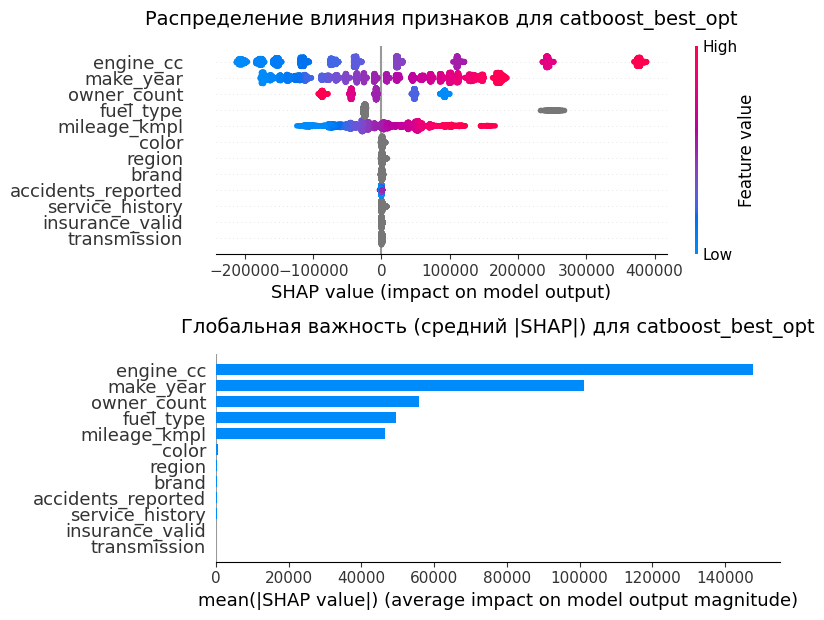

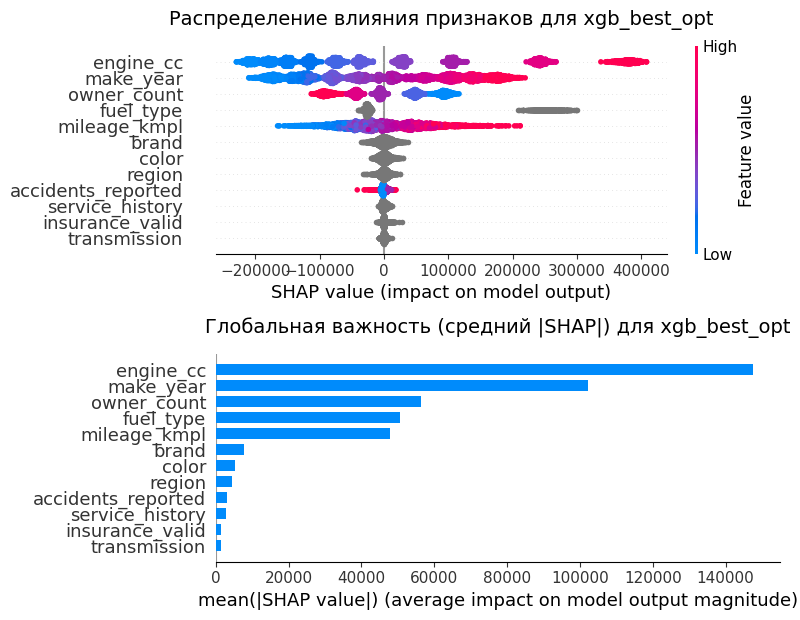

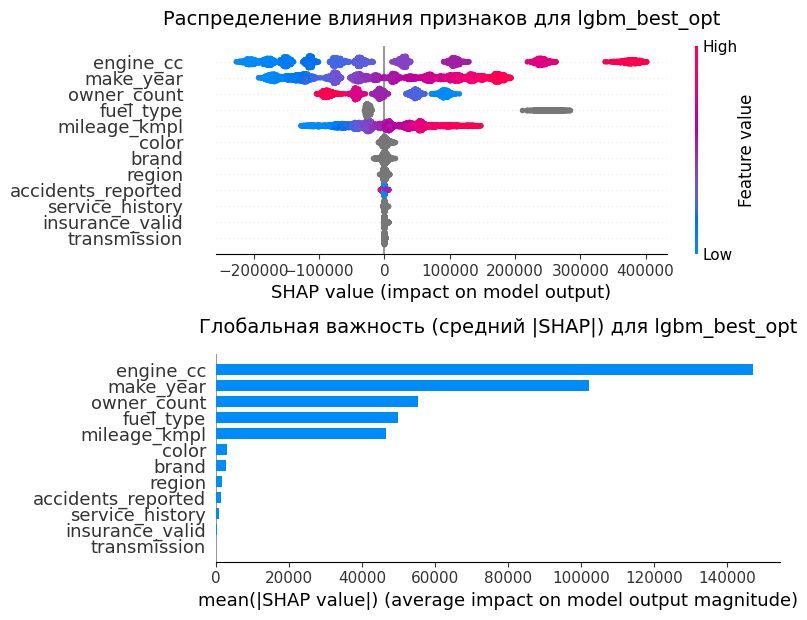

In [ ]:
for model, name in best_models:
    show_shap_analysis(model, name, X_val)

Анализ:
- лучшие модели показывают схожие результаты по важности признаков:
- в топе по важности находятся:
    - engine_cc - наиболее важный признак. Прослеживается прямая зависимость: чем выше объем двигателя, тем выше цена авто
    - make_year - чем новее авто, тем оно дороже
    - owner_count - обратная зависимость: чем больше владельцев, тем дешевле авто
    - fuel_type - значимый признак для предсказаний всех моделей
    - mileage_kmpl - важный признак с положительной связью с ценой на авто.
- остальные признаки существенно уступают по значимости


### Сравнение по бизнес-рискам

In [ ]:
results[['model_name', 'overpricing_rate', 'underpricing_loss']]

,model_name,overpricing_rate,underpricing_loss
0,catboost_best_opt,0.10200,6.078927e+07
0,cbr_model_base,0.10400,6.003099e+07
0,lgbm_best_opt,0.10225,6.325386e+07
0,lgbm_base,0.11350,6.613253e+07
0,xgb_best_opt,0.11800,6.864384e+07
0,xgb_model_base,0.11575,7.107491e+07


Анализ:
- catboost_best_opt лучшая с точки зрения бизнес-рисков: самый низкий overpricing_rate и underpricing_loss ниже других оптимизированных моделей. 

### Склонность к завышению и занижению по маркам

In [ ]:
def metrics_analysis(y_val_pred, y_val, X_val, metric_func, metric_name: str, groupby_feature: str):

    y_val_pred_series = pd.Series(data=y_val_pred, name='target')
    brand_analysis = pd.concat([y_val_pred_series, X_val[groupby_feature].reset_index(drop=True)], ignore_index=True, axis=1)
    brand_analysis.columns = ['target', groupby_feature]
    
    # Расчет метрики
    brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))
    brand_analysis_overpricing_rate = brand_analysis_overpricing_rate.sort_values()
    
    # Строим график
    ax = brand_analysis_overpricing_rate.plot.barh(color='royalblue', edgecolor='black')

    # Добавляем значения на столбцы
    for index, value in enumerate(brand_analysis_overpricing_rate):
        # Округляем значение до 3 знаков (настройте под себя, например, {:.1%} для процентов)
        label = f"{value:.3f}" 
        
        # Размещаем текст чуть правее самого столбца
        ax.text(
            x=value + (max(brand_analysis_overpricing_rate) * 0.01), 
            y=index,                                                 
            s=label,                                                 
            va='center',                                             
            ha='left',                                              
            fontsize=9                                              
        )

    # Настройка границ, чтобы текст справа не обрезался
    plt.xlim(0, max(brand_analysis_overpricing_rate) * 1.15)
    
    plt.title(f'{metric_name} по {groupby_feature}')
    plt.xlabel(f'{metric_name}')
    plt.tight_layout()
    plt.show()

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_24964/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


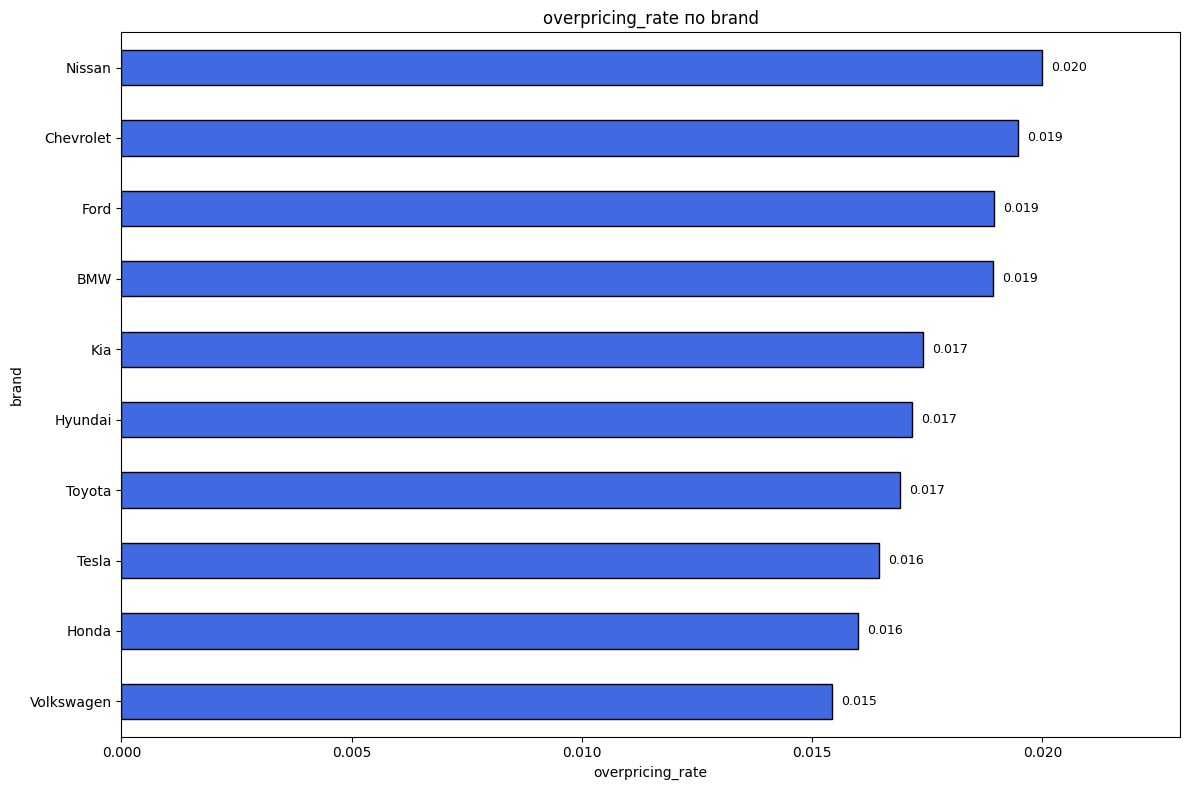

In [ ]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_overpricing_rate, metric_name='overpricing_rate',
    groupby_feature='brand'
)

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_24964/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


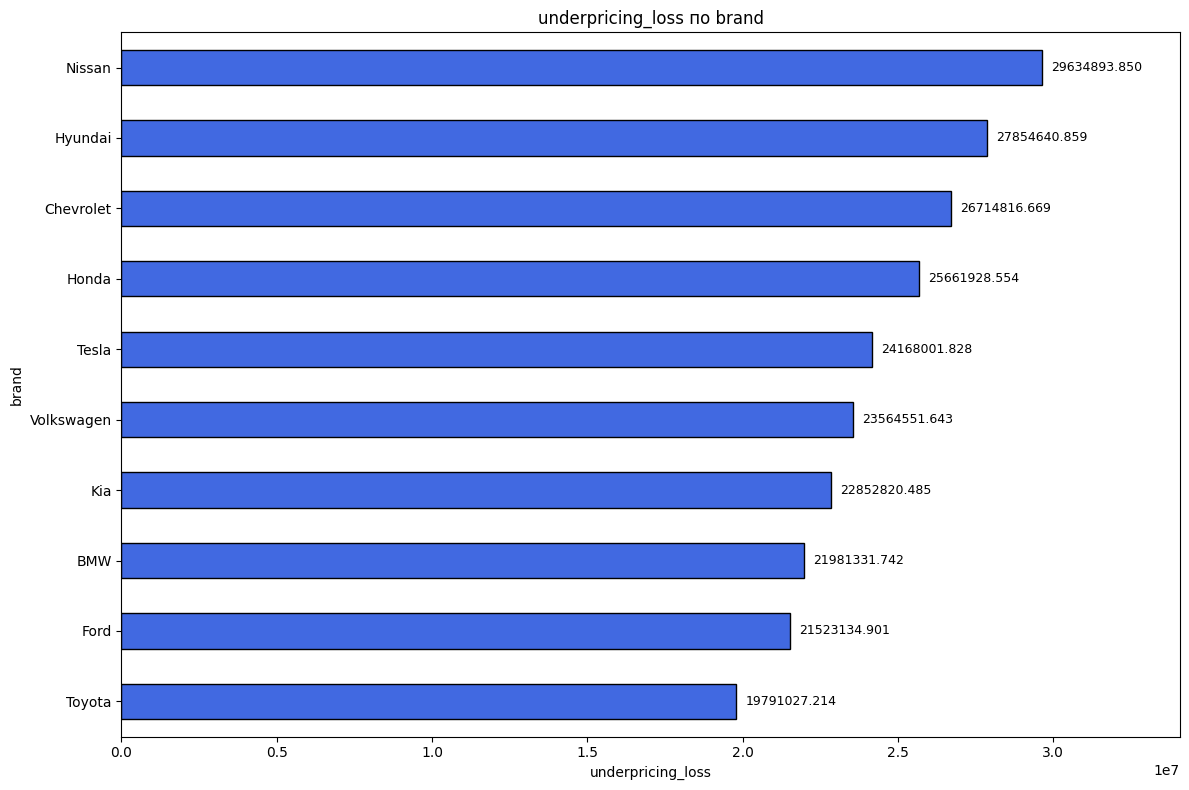

In [ ]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_underpricing_loss, metric_name='underpricing_loss',
    groupby_feature='brand'
)

Анализ:
- модель систематически завышает цену для марок Nissan, Chevrolet, BMW, Ford - наиболее высокие показатели по матрике overpricing_rate
- наиболее высокие потери от недооценки у марок: Nissan, Hyandai, Chevrolet, Honda - наболее высокие показатели по метрике underpricing_loss

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_24964/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


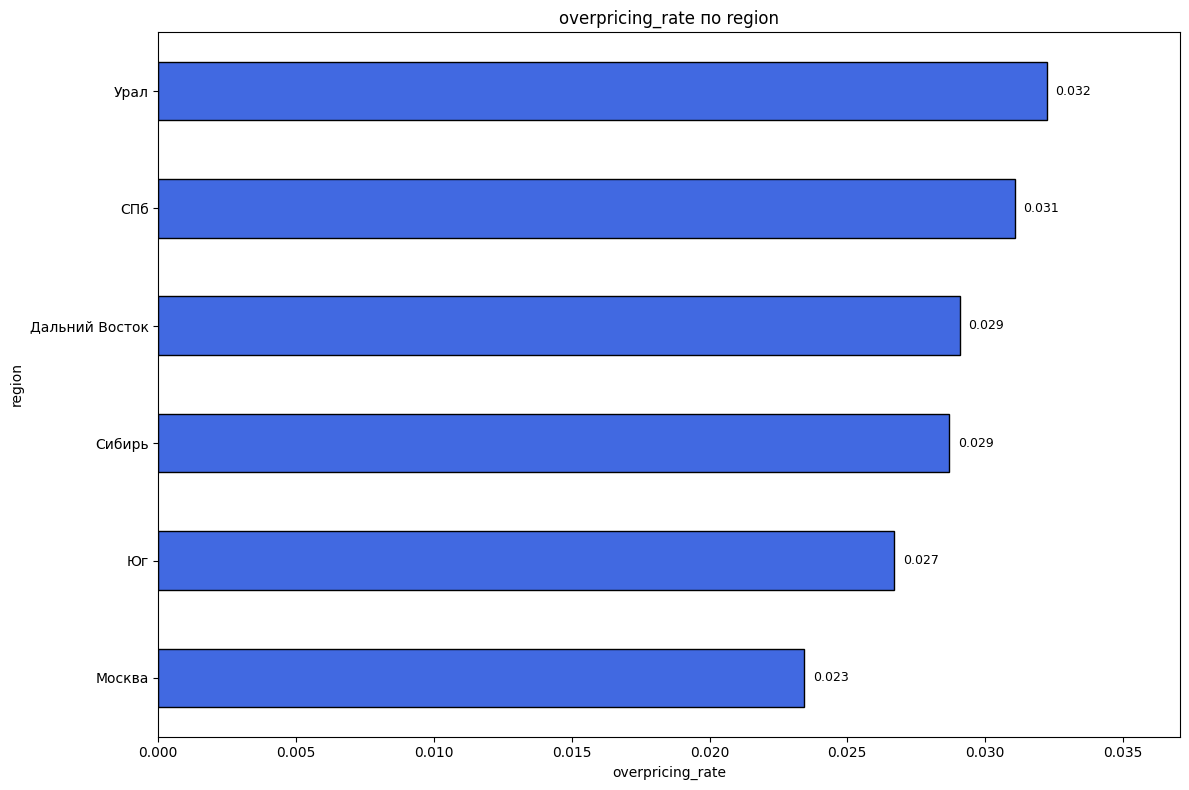

In [ ]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_overpricing_rate, metric_name='overpricing_rate',
    groupby_feature='region'
)

/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_24964/479580336.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brand_analysis_overpricing_rate = brand_analysis.groupby(groupby_feature)['target'].agg(lambda x: metric_func(y_val, x))


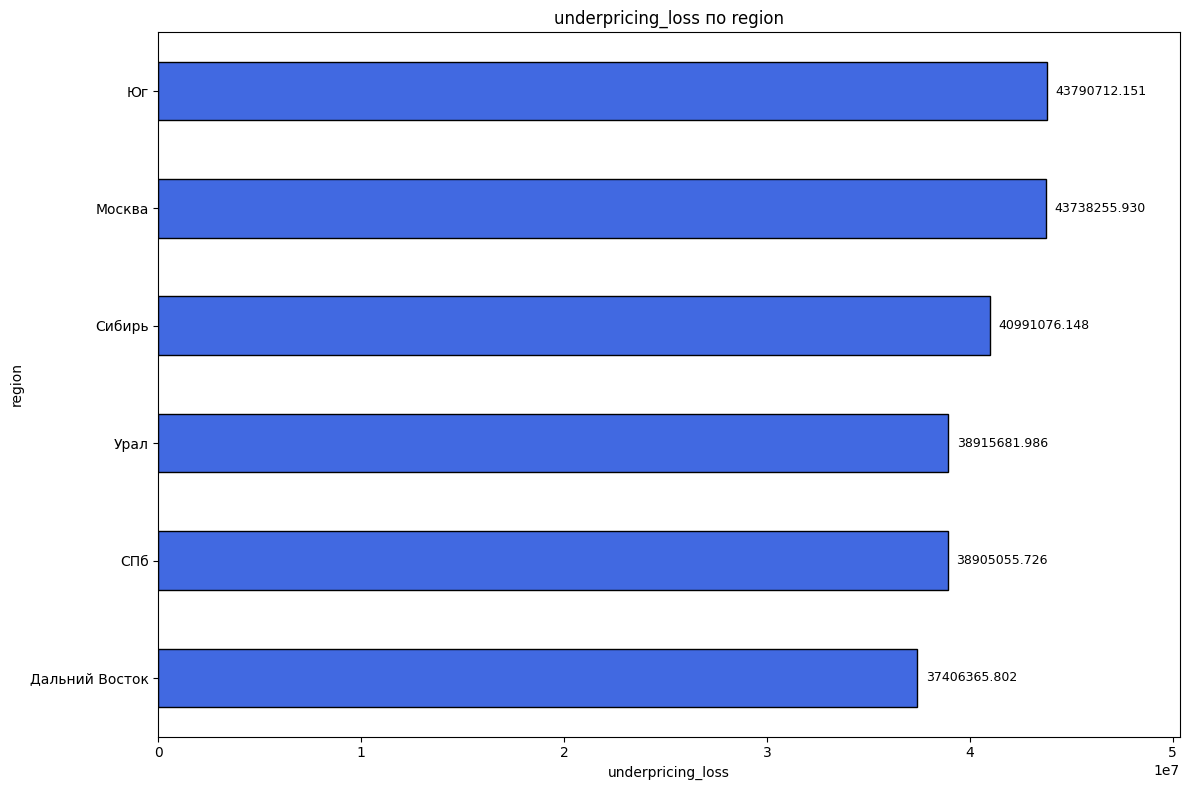

In [ ]:
metrics_analysis(
    y_val_pred=y_val_pred_catboost_best_opt, y_val=y_val, X_val=X_val, 
    metric_func=get_underpricing_loss, metric_name='underpricing_loss',
    groupby_feature='region'
)

Анализ:
- модель систематически завышает цену для регионов Урал, СПб - наиболее высокие показатели по матрике overpricing_rate
- наиболее высокие потери от недооценки у регионов: Юг, Москва - наболее высокие показатели по метрике underpricing_loss

---
## 7. Финальная проверка

In [ ]:
for col in cat_cols_feat:
	# приведение всех категориальных признаков к pd.categorical
	df_test[col] = df_test[col].astype('category')

In [ ]:
X_test = df_test.drop(columns='price_rub')
y_test = pd.Series(df_test['price_rub'], name='target')

In [ ]:
y_test_pred = catboost_best_opt.predict(X_test)
y_val_pred = catboost_best_opt.predict(X_val)

In [ ]:
results_test = calc_metrics(y_test, y_test_pred, model_name='catboost_best_opt на test')
results_val = calc_metrics(y_val, y_val_pred, model_name='catboost_best_opt на val')

pd.concat([results_val, results_test])

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,catboost_best_opt на val,0.1310,3.902806e+07,97337.433086,77828.464925,0.863502
0,catboost_best_opt на test,0.1345,1.971336e+07,95197.119568,76217.363201,0.873779


Анализ:

Модель показывает стабильные результаты по ключевым метрикам на validate и test
- наблюдается несущественное улучшение по метрикам rmse, mae, r2 (менее 1%)
- по метрике overpricing_rate небольшая просадка на 2%
- по метрике underpricing_loss на test существенное улучшение: почти -50%

Можно сделать вывод о том, что модель не переобучилась. Разработанная модель обладает высокой обощающей способностью.

---
## 8. Описание выводов и финальный вердикт

Подготовьте краткую аналитическую записку в конце ноутбука для Артёма (CEO) и Юли (Head of Data).

Какая библиотека дала лучший результат с точки зрения бизнес-метрик (Overpricing Rate / Underpricing Loss) и стандартных метрик качества.

Сделайте итоговую рекомендацию: какую библиотеку и с какими гиперпараметрами стоит внедрять в мобильное приложение AutoValue AI.

Общая информация:
- Проведен сравнительный анализ оптимизированных по гиперпараметрам моделей градиентного бустинга. 
- В сравнении участовали модели из библиотек XGBoost, CatBoost и LightGBM.
- По результатам сравнения была выявлена по ключевой бизнес метрике лучшая модель:  CatBoost с оптимизированными гиперпараметрами.

Наиболее важными при оценке авто признаками яляются:  
- engine_cc - наиболее важный признак. Прослеживается прямая зависимость: чем выше объем двигателя, тем выше цена авто
- make_year - чем новее авто, тем оно дороже
- owner_count - обратная зависимость: чем больше владельцев, тем дешевле авто
- fuel_type - значимый признак для предсказаний всех моделей
- mileage_kmpl - важный признак с положительной связью с ценой на авто. 

Финальная проверка:
- модель показывает стабильное качество на новых данных
- модель проверена на отложенной выборке и рекомендована к внедерению 
- метрики на финальной проверке: mae = 76217, overpricing_rate=0.134, underpricing_loss=1.971336e+07

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Арсений, по структуре ОК - просьба скорректировать после правок